### Meteorite Analysis (Data Analysis and Visualization)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# For reproducibility
np.random.seed(42)

# create data path 
data_path = "C:/Users/raadams/Documents/Notebooks/nasa_dataset/Meteorite_Landings.csv"

# read in using pandas and perform and inspection
df = pd.read_csv(data_path)
print(df.head(5)) # check data
print(df.info())
# Process for data analysis and visualization: 
# 1. define the problem and collect data
# 2. clean and prepare by removing duplicates, handling missing or null values, and fix inconsistencies
# 3. explore and analyze (EDA) using summary statistics, correlation checks, and pivot tables
# 4. visualize the findings 

       name   id nametype     recclass  mass (g)  fall    year    reclat  \
0    Aachen    1    Valid           L5      21.0  Fell  1880.0  50.77500   
1    Aarhus    2    Valid           H6     720.0  Fell  1951.0  56.18333   
2      Abee    6    Valid          EH4  107000.0  Fell  1952.0  54.21667   
3  Acapulco   10    Valid  Acapulcoite    1914.0  Fell  1976.0  16.88333   
4   Achiras  370    Valid           L6     780.0  Fell  1902.0 -33.16667   

     reclong           GeoLocation  
0    6.08333     (50.775, 6.08333)  
1   10.23333  (56.18333, 10.23333)  
2 -113.00000    (54.21667, -113.0)  
3  -99.90000     (16.88333, -99.9)  
4  -64.95000   (-33.16667, -64.95)  
<class 'pandas.DataFrame'>
RangeIndex: 45716 entries, 0 to 45715
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         45716 non-null  str    
 1   id           45716 non-null  int64  
 2   nametype     45716 non-null  str    
 3   recclass

In [21]:
# Rename fall category to something more intuitivie 
df.rename(columns={df.columns[5]: 'Fall Status'}, inplace=True)
df.rename(columns={df.columns[7]: 'Latitude'}, inplace=True)
df.rename(columns={df.columns[8]: 'Longtitude'}, inplace=True)

# rename columns to something simple and easier to name
df = df.rename(
        columns={
            "fall": "fall_status",
            "mass (g)": "mass_grams",
            "reclat": "latitude",
            "reclong": "longitude",
        }
    )

# Check missing values in each column
print(df.isnull().sum())

# Clean and prepare data 
df = df.drop_duplicates(subset=['id'])

# convert year
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

# filter out anomalous year data 
df.loc[(df["year"] < 800) | (df["year"] > 2026), "year"] = pd.NA

# convert mass into kg for better visualization (standard in STEM)
df["mass_kg"] = df["mass_grams"] / 1000.0

df["log_mass"] = np.log10(df["mass_grams"].replace(0, np.nan))

print(df.head())
# Current objective: do data processing and data analysis 
# Future goal: make classification model 


name              0
id                0
nametype          0
recclass          0
mass_grams      131
Fall Status       0
year            291
Latitude       7315
Longtitude     7315
GeoLocation    7315
dtype: int64
       name   id nametype     recclass  mass_grams Fall Status  year  \
0    Aachen    1    Valid           L5        21.0        Fell  1880   
1    Aarhus    2    Valid           H6       720.0        Fell  1951   
2      Abee    6    Valid          EH4    107000.0        Fell  1952   
3  Acapulco   10    Valid  Acapulcoite      1914.0        Fell  1976   
4   Achiras  370    Valid           L6       780.0        Fell  1902   

   Latitude  Longtitude           GeoLocation  mass_kg  log_mass  
0  50.77500     6.08333     (50.775, 6.08333)    0.021  1.322219  
1  56.18333    10.23333  (56.18333, 10.23333)    0.720  2.857332  
2  54.21667  -113.00000    (54.21667, -113.0)  107.000  5.029384  
3  16.88333   -99.90000     (16.88333, -99.9)    1.914  3.281942  
4 -33.16667   -64.9

In [22]:
# First let's filter between meteorites seen falling vs just found on the ground. 
# It is part of the reason why I renamed the "Fell" column 

# Filter for meteorites seen falling
fell_df = df[df["Fall Status"] == "Fell"]
print("Meteorites seen falling count:", len(fell_df))

# Filter for meteorites that weigh over 100,000 grams (100 kg)
heavy_df = df[df["mass_kg"] > 100]
print("Meteorites that are heavy count:", len(heavy_df))

Meteorites seen falling count: 1107
Meteorites that are heavy count: 282


In [28]:
# Group by status and calculate summary stats for mass
df.groupby("Fall Status")["mass_kg"].agg(["count", "mean", "median", "max"])
print(df)

             name     id nametype              recclass  mass_grams  \
0          Aachen      1    Valid                    L5        21.0   
1          Aarhus      2    Valid                    H6       720.0   
2            Abee      6    Valid                   EH4    107000.0   
3        Acapulco     10    Valid           Acapulcoite      1914.0   
4         Achiras    370    Valid                    L6       780.0   
...           ...    ...      ...                   ...         ...   
45711  Zillah 002  31356    Valid               Eucrite       172.0   
45712      Zinder  30409    Valid  Pallasite, ungrouped        46.0   
45713        Zlin  30410    Valid                    H4         3.3   
45714   Zubkovsky  31357    Valid                    L6      2167.0   
45715  Zulu Queen  30414    Valid                  L3.7       200.0   

      Fall Status  year  Latitude  Longtitude             GeoLocation  \
0            Fell  1880  50.77500     6.08333       (50.775, 6.08333)   
1

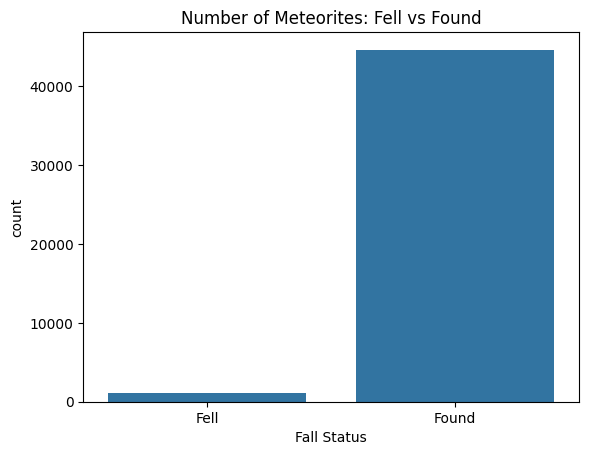

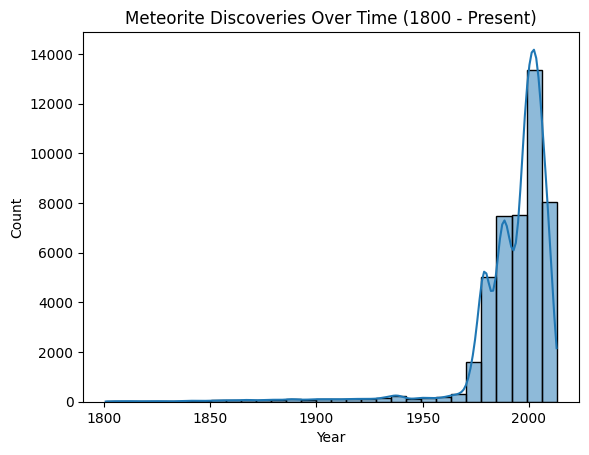

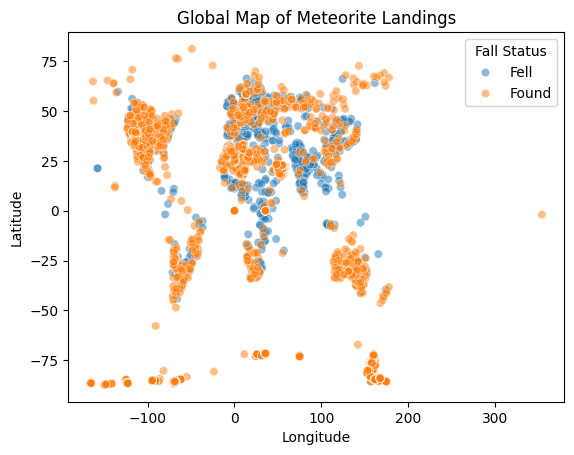

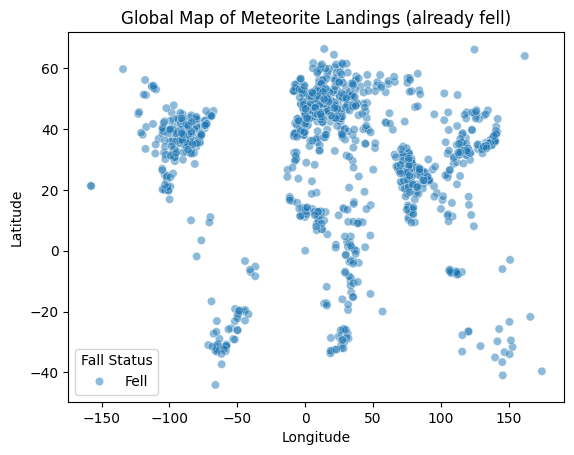

<Axes: xlabel='Longtitude', ylabel='Latitude'>

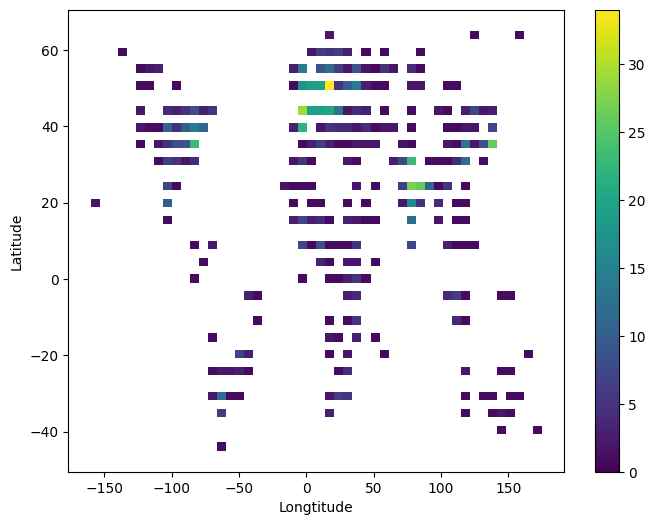

In [42]:
# Count how many of each recclass exist (this can be used for classification in the future)
df["recclass"].value_counts().head(5) 

# Let's create a bar chart for categorical data
sns.countplot(data=df, x="Fall Status")
plt.title("Number of Meteorites: Fell vs Found")
plt.show()

# Filter for year >= 1800
recent_df = df[df["year"] >= 1800]

sns.histplot(data=recent_df, x="year", bins=30, kde=True)
plt.title("Meteorite Discoveries Over Time (1800 - Present)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# Need to overlay over global map (get more from year)
sns.scatterplot(data=df, x="Longtitude", y="Latitude", hue="Fall Status", alpha=0.5)
plt.title("Global Map of Meteorite Landings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# What has fell 
fell_df = df[df["Fall Status"] == "Fell"]
sns.scatterplot(data=fell_df, x="Longtitude", y="Latitude", hue="Fall Status", alpha=0.5)
plt.title("Global Map of Meteorite Landings (already fell)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# round out the longitude and latitutde values 
fell_df["Longtitude"] = round(fell_df["Longtitude"]/5)*5
fell_df["Latitude"] = round(fell_df["Latitude"]/5)*5

plt.figure(figsize=(8, 6))
sns.histplot(
    data=fell_df, 
    x='Longtitude', 
    y='Latitude', 
    bins=50, 
    cbar=True, 
    cmap='viridis'
)


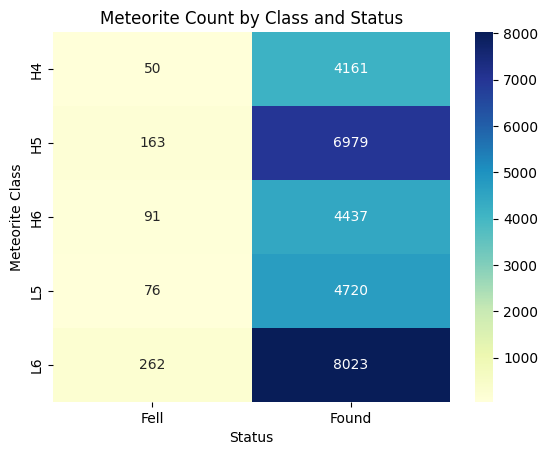

In [43]:
# Create a pivot table counting occurrences of top classes by status
# Get top 5 most common classes first
top_5_classes = df["recclass"].value_counts().head(5).index
filtered_df = df[df["recclass"].isin(top_5_classes)]

# Step 2: Make the pivot table
pivot_df = filtered_df.pivot_table(
    index="recclass", columns="Fall Status", values="id", aggfunc="count"
)

# Step 3: Plot the heatmap
sns.heatmap(pivot_df, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Meteorite Count by Class and Status")
plt.xlabel("Status")
plt.ylabel("Meteorite Class")
plt.show()

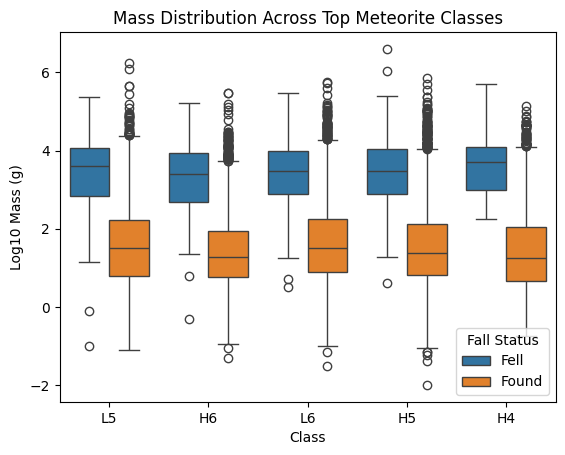

In [ ]:

# fFilter for top classes
top_classes = df["recclass"].value_counts().head(5).index
box_df = df[df["recclass"].isin(top_classes)]

# Make boxplot (get mass by category in log scale)
sns.boxplot(data=box_df, x="recclass", y="log_mass", hue="Fall Status")
plt.title("Mass Distribution Across Top Meteorite Classes")
plt.xlabel("Class")
plt.ylabel("Log10 Mass (g)")
plt.show()

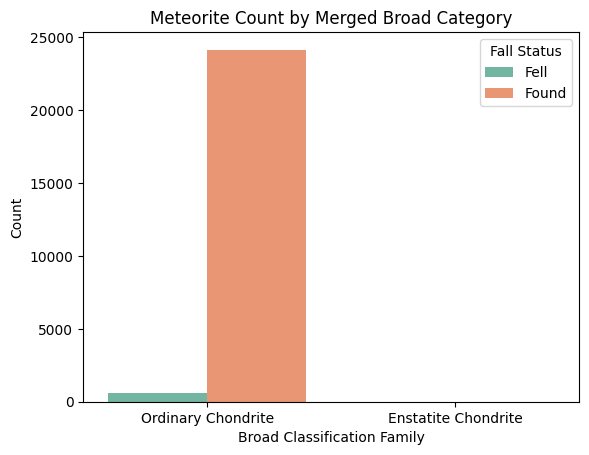

In [44]:
# Create a reference mapping table 
class_lookup = pd.DataFrame(
    {
        "recclass": ["L6", "H5", "L5", "H6", "EH4"],
        "broad_type": [
            "Ordinary Chondrite",
            "Ordinary Chondrite",
            "Ordinary Chondrite",
            "Ordinary Chondrite",
            "Enstatite Chondrite",
        ],
    }
)

# merge reference data into your main dataframe (here is how to practice merge in assessments)
merged_df = pd.merge(df, class_lookup, on="recclass", how="inner")

# plot count by broad type using the merged column
sns.countplot(
    data=merged_df, x="broad_type", hue="Fall Status", palette="Set2"
)
plt.title("Meteorite Count by Merged Broad Category")
plt.xlabel("Broad Classification Family")
plt.ylabel("Count")
plt.show()

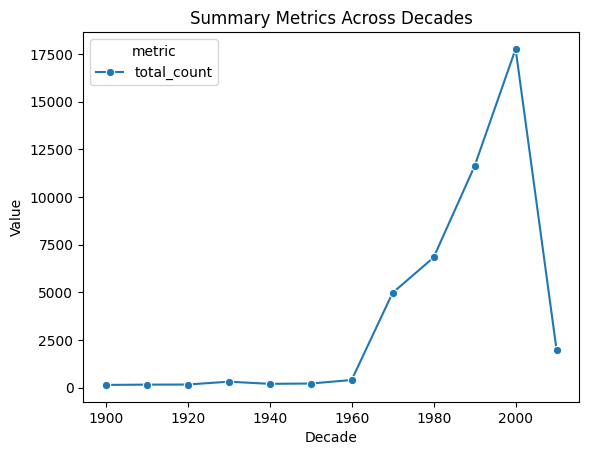

In [ ]:
# Group by year to get summary metrics (wide format)
decade_df = df[df["year"] >= 1900].copy()
decade_df["decade"] = (decade_df["year"] // 10) * 10

summary_wide = (
    decade_df.groupby("decade")[["mass_kg", "id"]].agg({"mass_kg": "mean", "id": "count"}).reset_index()
)
summary_wide.columns = ["decade", "avg_mass", "total_count"]

# Melt the table from wide to long format
summary_long = pd.melt(
    summary_wide,
    id_vars=["decade"],
    value_vars="total_count",
    var_name="metric",
    value_name="value",
)

# Line plot showing melted metrics
sns.lineplot(
    data=summary_long,
    x="decade",
    y="value",
    hue="metric",
    marker="o",
)
plt.title("Line Plot Count Across Decades")
plt.xlabel("Decade")
plt.ylabel("Value")
plt.show()